# Modeling — RGB HOG + MLP

**Purpose:** We rebuild the strict modeling manifest, run one clean notebook-defined RGB HOG + MLP tuning round, and inspect only the final selected MLP result using overwrite-safe artifacts.

**Notebook Rules**
- We keep logic inside `src/`.
- We use the strict modeling manifest only.
- We tune against an explicit trial list defined in this notebook.
- We save only one final best MLP artifact set and overwrite it on reruns.

In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import applyPlotStyle, ensureProjectDirs, printProjectSummary, setGlobalSeed

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)

projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


## Strict Modeling Manifest

We rebuild the strict modeling manifest first so the MLP search uses the same leakage-safe crop list as the classical baselines.

In [2]:
# We build the strict modeling manifest and inspect the saved summary.

from src.data import runModelingManifestBuilder

modelingResult = runModelingManifestBuilder(projectConfig)
modelingSummary = modelingResult["modelingSummary"]

modelingSummary

{'rawCropCount': 1584,
 'strictModelingCropCount': 1580,
 'excludedDuplicateCropCount': 4,
 'excludedCrossSplitDuplicateCropCount': 2,
 'strictUniqueSourceImageCount': 1061,
 'strictTrainCropCount': 1097,
 'strictValCropCount': 245,
 'strictTestCropCount': 238}

## Final MLP Tuning Plan

We run one compact final tuning round around the strongest HOG + MLP setup and check only the last reasonable interaction effects.

In [3]:
# We run one final focused MLP tuning round around the two strongest families we found so far.

from dataclasses import replace
import pandas as pd

from src.models import MlpTrialSpec

# We keep the strongest test-family anchor.
wideAnchorTrialSpec = MlpTrialSpec(
    trialName="final_wide_anchor",
    hiddenDims=(1024, 512),
    dropoutRate=0.30,
    useBatchNorm=True,
    imageSize=144,
    pixelsPerCell=(16, 16),
    orientations=9,
    colorMode="rgb",
    batchSize=64,
    learningRate=1e-3,
    weightDecay=1e-3,
    numEpochs=120,
    earlyStoppingPatience=20,
    labelSmoothing=0.0,
    useClassWeights=True,
    randomSeed=projectConfig.seed,
)

# We keep the strongest validation-family anchor.
deepAnchorTrialSpec = MlpTrialSpec(
    trialName="final_deep_anchor",
    hiddenDims=(1024, 512, 256),
    dropoutRate=0.35,
    useBatchNorm=True,
    imageSize=144,
    pixelsPerCell=(16, 16),
    orientations=9,
    colorMode="rgb",
    batchSize=64,
    learningRate=1e-3,
    weightDecay=1e-3,
    numEpochs=120,
    earlyStoppingPatience=20,
    labelSmoothing=0.0,
    useClassWeights=True,
    randomSeed=projectConfig.seed,
)

mlpTrialSpecList = [
    # We keep the two main anchors.
    wideAnchorTrialSpec,
    deepAnchorTrialSpec,

    # We refine the wide family locally.
    replace(
        wideAnchorTrialSpec,
        trialName="final_wide_do035",
        dropoutRate=0.35,
    ),
    replace(
        wideAnchorTrialSpec,
        trialName="final_wide_wd15e3",
        weightDecay=1.5e-3,
    ),
    replace(
        wideAnchorTrialSpec,
        trialName="final_wide_lr8e4",
        learningRate=8e-4,
    ),
    replace(
        wideAnchorTrialSpec,
        trialName="final_wide_bs32",
        batchSize=32,
    ),
    replace(
        wideAnchorTrialSpec,
        trialName="final_wide_do035_wd15e3",
        dropoutRate=0.35,
        weightDecay=1.5e-3,
    ),

    # We refine the deep family locally.
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_do030",
        dropoutRate=0.30,
    ),
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_do040",
        dropoutRate=0.40,
    ),
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_wd15e3",
        weightDecay=1.5e-3,
    ),
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_lr8e4",
        learningRate=8e-4,
    ),
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_bs32",
        batchSize=32,
    ),
    replace(
        deepAnchorTrialSpec,
        trialName="final_deep_do035_wd15e3",
        dropoutRate=0.35,
        weightDecay=1.5e-3,
    ),
]

mlpTrialPlanDf = pd.DataFrame(
    [
        {
            "trialName": trialSpec.trialName,
            "hiddenDims": str(trialSpec.hiddenDims),
            "dropoutRate": trialSpec.dropoutRate,
            "useBatchNorm": trialSpec.useBatchNorm,
            "imageSize": trialSpec.imageSize,
            "pixelsPerCell": str(trialSpec.pixelsPerCell),
            "orientations": trialSpec.orientations,
            "colorMode": trialSpec.colorMode,
            "batchSize": trialSpec.batchSize,
            "learningRate": trialSpec.learningRate,
            "weightDecay": trialSpec.weightDecay,
            "numEpochs": trialSpec.numEpochs,
            "earlyStoppingPatience": trialSpec.earlyStoppingPatience,
            "labelSmoothing": trialSpec.labelSmoothing,
            "useClassWeights": trialSpec.useClassWeights,
        }
        for trialSpec in mlpTrialSpecList
    ]
)

print(f"Number of planned trials: {len(mlpTrialSpecList)}")
mlpTrialPlanDf

Number of planned trials: 13


,trialName,hiddenDims,dropoutRate,useBatchNorm,imageSize,pixelsPerCell,orientations,colorMode,batchSize,learningRate,weightDecay,numEpochs,earlyStoppingPatience,labelSmoothing,useClassWeights
0,final_wide_anchor,"(1024, 512)",0.30,True,144,"(16, 16)",9,rgb,64,0.0010,0.0010,120,20,0.0,True
1,final_deep_anchor,"(1024, 512, 256)",0.35,True,144,"(16, 16)",9,rgb,64,0.0010,0.0010,120,20,0.0,True
2,final_wide_do035,"(1024, 512)",0.35,True,144,"(16, 16)",9,rgb,64,0.0010,0.0010,120,20,0.0,True
3,final_wide_wd15e3,"(1024, 512)",0.30,True,144,"(16, 16)",9,rgb,64,0.0010,0.0015,120,20,0.0,True
4,final_wide_lr8e4,"(1024, 512)",0.30,True,144,"(16, 16)",9,rgb,64,0.0008,0.0010,120,20,0.0,True
5,final_wide_bs32,"(1024, 512)",0.30,True,144,"(16, 16)",9,rgb,32,0.0010,0.0010,120,20,0.0,True
6,final_wide_do035_wd15e3,"(1024, 512)",0.35,True,144,"(16, 16)",9,rgb,64,0.0010,0.0015,120,20,0.0,True
7,final_deep_do030,"(1024, 512, 256)",0.30,True,144,"(16, 16)",9,rgb,64,0.0010,0.0010,120,20,0.0,True
8,final_deep_do040,"(1024, 512, 256)",0.40,True,144,"(16, 16)",9,rgb,64,0.0010,0.0010,120,20,0.0,True
9,final_deep_wd15e3,"(1024, 512, 256)",0.35,True,144,"(16, 16)",9,rgb,64,0.0010,0.0015,120,20,0.0,True


## Run the Final MLP Search

This cell runs the notebook-defined trial list, prints live progress, and overwrites the saved MLP artifacts with only the final selected winner.

In [4]:
# We run the final HOG + MLP search and keep only the final selected artifact set.

from src.models import runMlpHyperparameterSearch

mlpResult = runMlpHyperparameterSearch(
    projectConfig=projectConfig,
    trialSpecList=mlpTrialSpecList,
    verbose=True,
)

mlpResult["bestTrialSpec"]

[search] featureBuild | trial=1/13 | key=(144, (16, 16), 9, 'rgb')
[search] trialStart | index=1/13 | name=final_wide_anchor
[final_wide_anchor] start | hog(imageSize=144, pixelsPerCell=(16, 16), orientations=9, colorMode=rgb) | mlp(hiddenDims=(1024, 512), dropoutRate=0.3, useBatchNorm=True) | opt(batchSize=64, learningRate=0.001, weightDecay=0.001, labelSmoothing=0.0, useClassWeights=True)
[final_wide_anchor] epoch=001/120 | lr=0.001000 | trainLoss=1.5069 | valLoss=1.6408 | trainMacroF1=0.4058 | valMacroF1=0.3898 | bestValMacroF1=0.3898
[final_wide_anchor] epoch=002/120 | lr=0.001000 | trainLoss=1.0813 | valLoss=1.3693 | trainMacroF1=0.5791 | valMacroF1=0.5012 | bestValMacroF1=0.5012
[final_wide_anchor] epoch=003/120 | lr=0.001000 | trainLoss=0.8477 | valLoss=1.1943 | trainMacroF1=0.6840 | valMacroF1=0.5864 | bestValMacroF1=0.5864
[final_wide_anchor] epoch=004/120 | lr=0.001000 | trainLoss=0.6552 | valLoss=1.0278 | trainMacroF1=0.7501 | valMacroF1=0.6589 | bestValMacroF1=0.6589
[final

MlpTrialSpec(trialName='final_deep_wd15e3', hiddenDims=(1024, 512, 256), dropoutRate=0.35, useBatchNorm=True, imageSize=144, pixelsPerCell=(16, 16), orientations=9, colorMode='rgb', batchSize=64, learningRate=0.001, weightDecay=0.0015, numEpochs=120, earlyStoppingPatience=20, labelSmoothing=0.0, useClassWeights=True, randomSeed=27)

## Best Validation Config

We show only the single best validation config from the saved tuning summary.

In [5]:
# We load the saved tuning summary and show only the single best validation config.

mlpTuningSummaryDf = pd.read_csv(mlpResult["artifactPathDict"]["tuningSummaryPath"])

bestMlpConfigDf = (
    mlpTuningSummaryDf
    .sort_values(by=["valMacroF1", "testMacroF1", "valAccuracy"], ascending=False)
    .head(1)[[
        "trialName",
        "hiddenDims",
        "dropoutRate",
        "useBatchNorm",
        "imageSize",
        "pixelsPerCell",
        "orientations",
        "colorMode",
        "batchSize",
        "learningRate",
        "weightDecay",
        "numEpochs",
        "earlyStoppingPatience",
        "labelSmoothing",
        "useClassWeights",
        "bestEpoch",
        "valMacroF1",
    ]]
    .reset_index(drop=True)
)

bestMlpConfigDf

,trialName,hiddenDims,dropoutRate,useBatchNorm,imageSize,pixelsPerCell,orientations,colorMode,batchSize,learningRate,weightDecay,numEpochs,earlyStoppingPatience,labelSmoothing,useClassWeights,bestEpoch,valMacroF1
0,final_deep_wd15e3,"(1024, 512, 256)",0.35,True,144,"(16, 16)",9,rgb,64,0.001,0.0015,120,20,0.0,True,26,0.787819


## Final Train, Validation, and Test Metrics

We show the final split-level metrics for the selected best MLP run.

In [6]:
# We load the saved metric summary and show the final clean metric table.

mlpMetricSummaryDf = pd.read_csv(mlpResult["artifactPathDict"]["metricSummaryPath"])

mlpFinalMetricsDf = (
    mlpMetricSummaryDf[[
        "split",
        "accuracy",
        "macroPrecision",
        "macroRecall",
        "macroF1",
        "weightedF1",
    ]]
    .copy()
    .round(4)
)

mlpFinalMetricsDf

,split,accuracy,macroPrecision,macroRecall,macroF1,weightedF1
0,train,0.9754,0.9787,0.9790,0.9787,0.9753
1,val,0.8000,0.7845,0.7932,0.7878,0.8000
2,test,0.7857,0.8027,0.8010,0.7990,0.7853


In [7]:
# We compare the best validation trial and the best observed test trial side by side.

mlpTuningSummaryDf = pd.read_csv(mlpResult["artifactPathDict"]["tuningSummaryPath"])

bestValTrialDf = (
    mlpTuningSummaryDf
    .sort_values(by=["valMacroF1", "testMacroF1", "valAccuracy"], ascending=False)
    .head(1)
)

bestTestTrialDf = (
    mlpTuningSummaryDf
    .sort_values(by=["testMacroF1", "valMacroF1", "testAccuracy"], ascending=False)
    .head(1)
)

bestValTrialDf[["trialName", "valMacroF1", "testMacroF1", "valAccuracy", "testAccuracy"]], \
bestTestTrialDf[["trialName", "valMacroF1", "testMacroF1", "valAccuracy", "testAccuracy"]]

(           trialName  valMacroF1  testMacroF1  valAccuracy  testAccuracy
 0  final_deep_wd15e3    0.787819     0.798966          0.8      0.785714,
            trialName  valMacroF1  testMacroF1  valAccuracy  testAccuracy
 3  final_wide_anchor    0.776607      0.81405     0.791837      0.798319)

## Training Curves

We plot the saved history of the final selected MLP run so we can inspect the train-vs-validation behavior clearly.

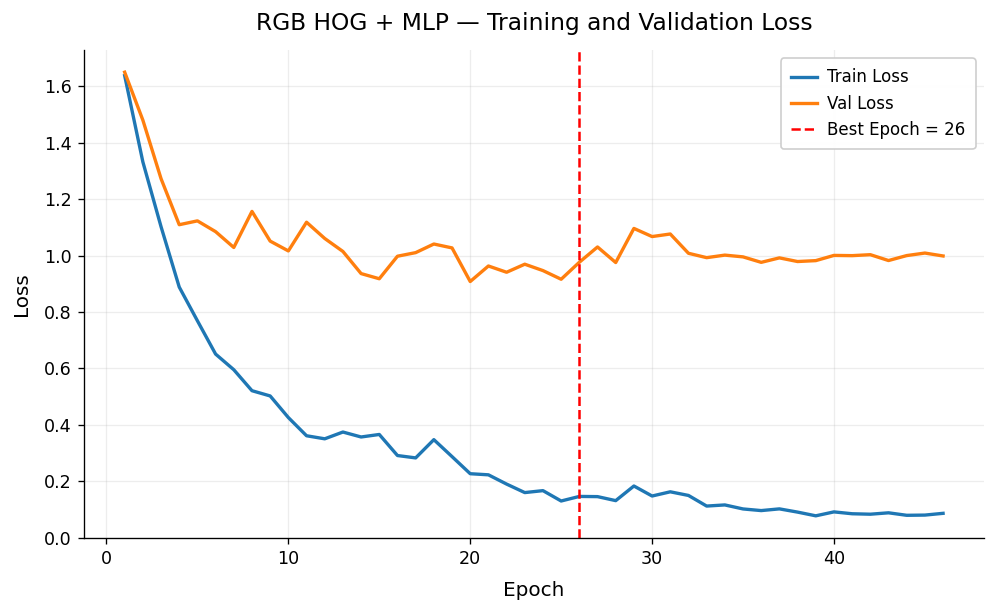

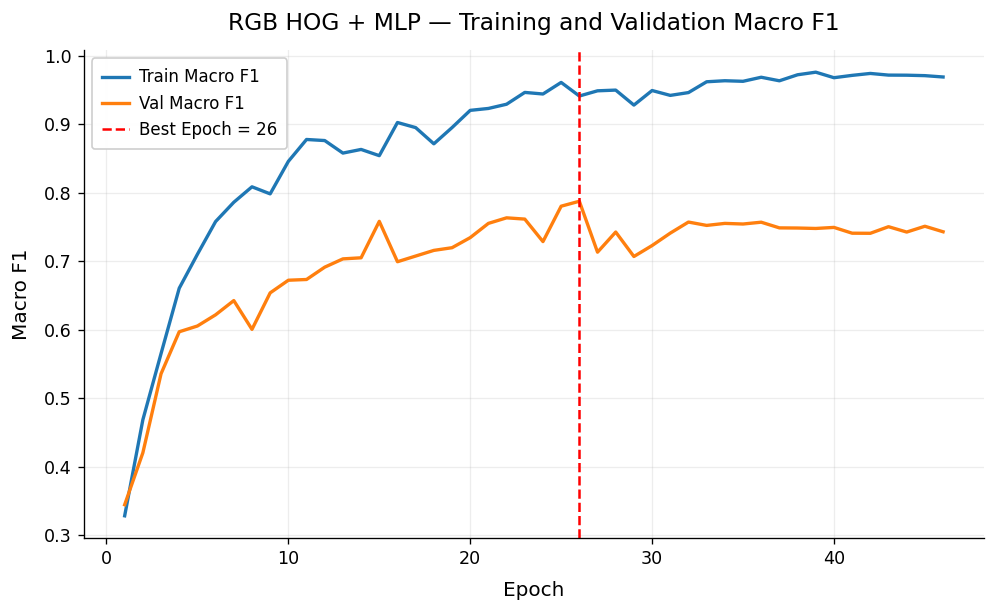

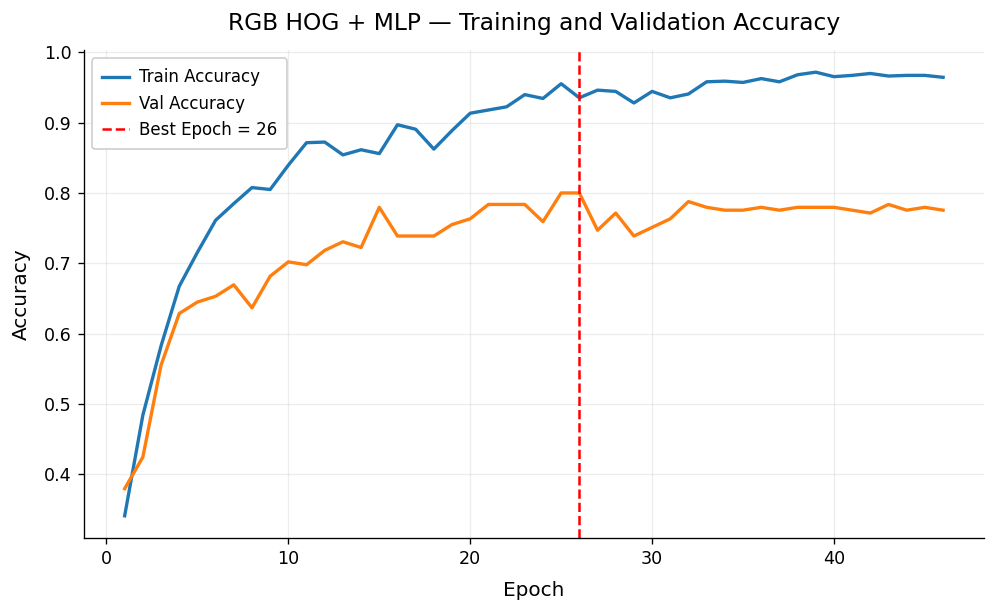

['mlpTrainingValidationAccuracy.png',
 'mlpTrainingValidationLoss.png',
 'mlpTrainingValidationMacroF1.png']

In [14]:
# We recreate and save the MLP training curves directly from the saved history.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

mlpFigureDir = projectConfig.figuresDir / "mlp"
mlpFigureDir.mkdir(parents=True, exist_ok=True)

mlpTuningSummaryDf = pd.read_csv(mlpResult["artifactPathDict"]["tuningSummaryPath"])
mlpHistoryDf = pd.read_csv(mlpResult["artifactPathDict"]["historyPath"])

bestEpoch = int(
    mlpTuningSummaryDf.sort_values(
        by=["valMacroF1", "testMacroF1", "valAccuracy"],
        ascending=False,
    ).iloc[0]["bestEpoch"]
)

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["trainLoss"], label="Train Loss")
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["valLoss"], label="Val Loss")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RGB HOG + MLP — Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(mlpFigureDir / "mlpTrainingValidationLoss.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["trainMacroF1"], label="Train Macro F1")
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["valMacroF1"], label="Val Macro F1")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("RGB HOG + MLP — Training and Validation Macro F1")
plt.legend()
plt.tight_layout()
plt.savefig(mlpFigureDir / "mlpTrainingValidationMacroF1.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["trainAccuracy"], label="Train Accuracy")
plt.plot(mlpHistoryDf["epoch"], mlpHistoryDf["valAccuracy"], label="Val Accuracy")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RGB HOG + MLP — Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(mlpFigureDir / "mlpTrainingValidationAccuracy.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

sorted(path.name for path in mlpFigureDir.glob("mlpTrainingValidation*.png"))

### Interpretation of the MLP Training Curves

The training curves show that the HOG + MLP model learns the task quickly in the first part of training. Training loss decreases steadily, while validation loss drops early and then stabilizes at a much higher level. At the same time, both validation macro-F1 and validation accuracy improve clearly at first and then flatten. The selected best epoch is around the point where validation macro-F1 reaches its peak before later epochs mostly improve the training fit without producing a real validation gain.

This pattern indicates **controlled overfitting** rather than model collapse. The model continues to fit the training data very strongly, but the validation metrics stop improving at the same pace. That is why the checkpoint is selected by **validation macro-F1** instead of by the final epoch or by the minimum validation loss. For this project, that is the correct selection rule because the dataset is multiclass and imbalanced, so balanced class performance matters more than raw loss alone.

**Best Epochs** are on the basis of our main metric **macroF1**

## Confusion Matrices

We draw clean and spacious validation and test confusion matrices for the final selected MLP run.

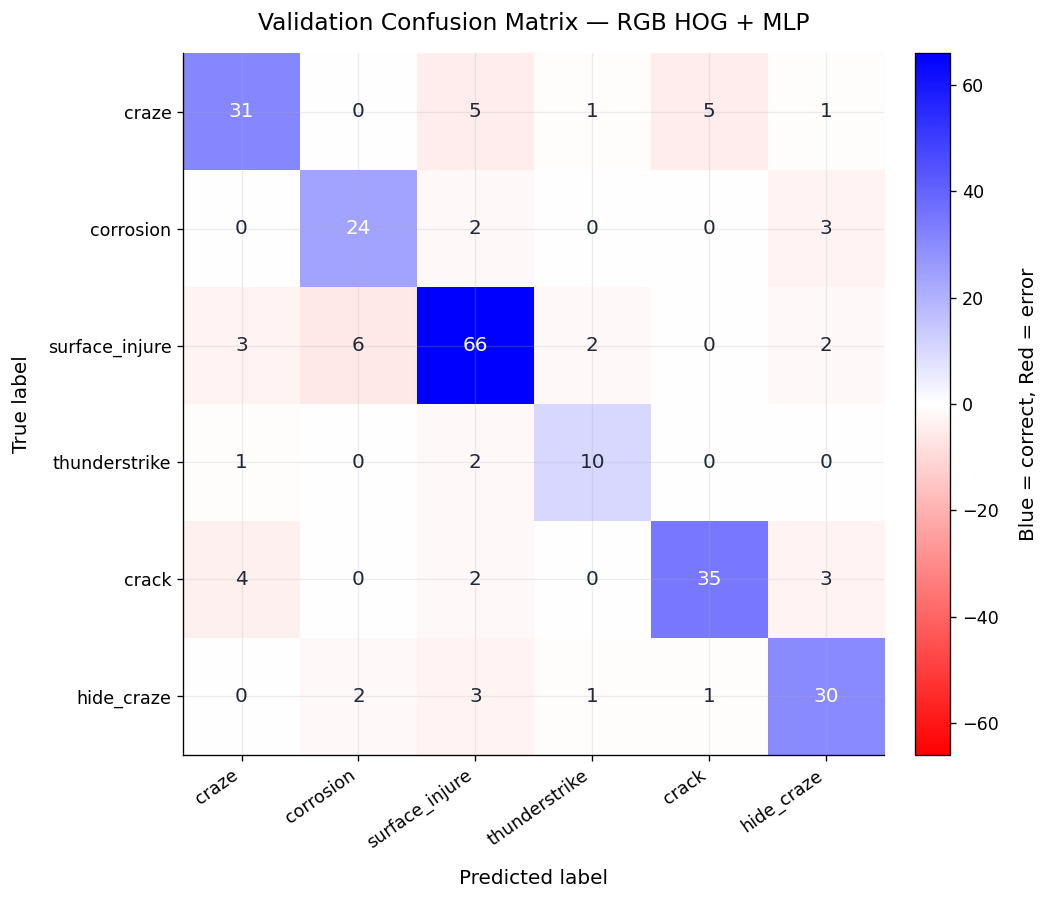

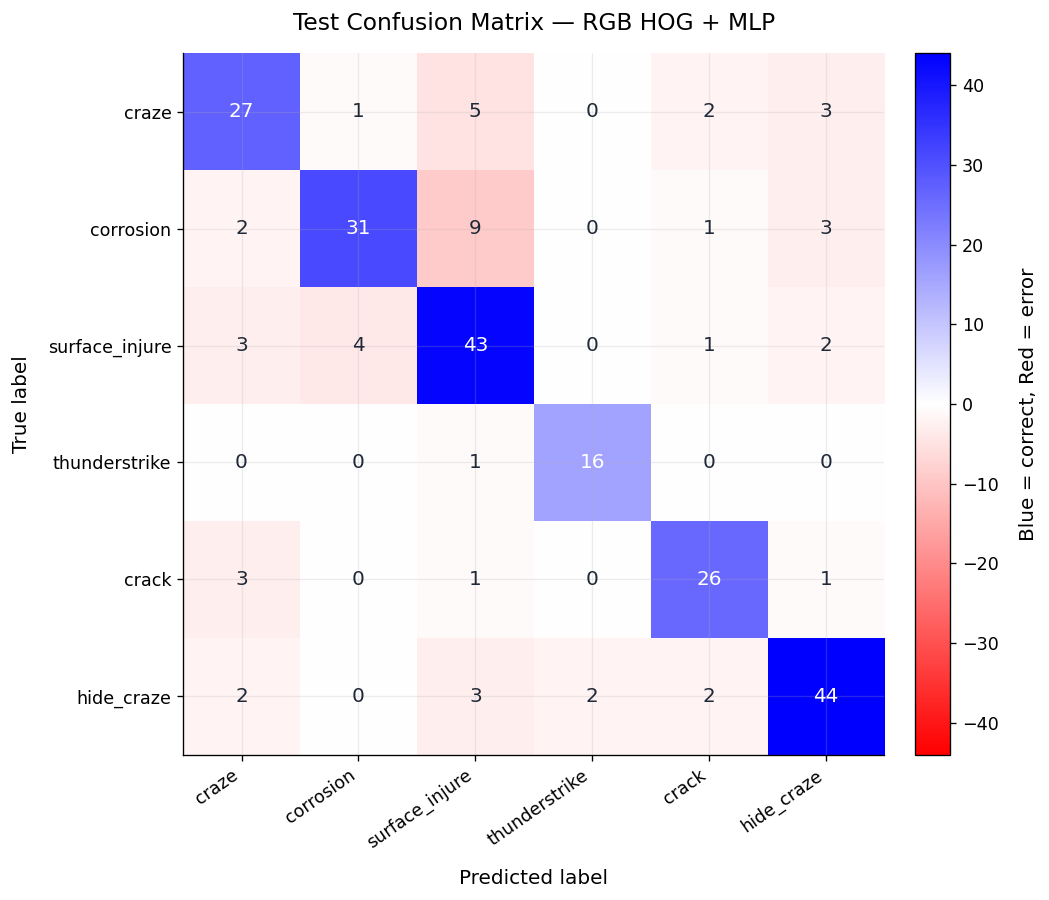

['mlpTestConfusionMatrix.png', 'mlpValidationConfusionMatrix.png']

In [15]:
# We recreate and save the MLP confusion matrices directly from the saved prediction files.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

mlpFigureDir = projectConfig.figuresDir / "mlp"
mlpFigureDir.mkdir(parents=True, exist_ok=True)

mlpValPredictionDf = pd.read_csv(mlpResult["artifactPathDict"]["valPredictionsPath"])
mlpTestPredictionDf = pd.read_csv(mlpResult["artifactPathDict"]["testPredictionsPath"])

valConfusionMatrix = confusion_matrix(
    mlpValPredictionDf["trueClassName"],
    mlpValPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

testConfusionMatrix = confusion_matrix(
    mlpTestPredictionDf["trueClassName"],
    mlpTestPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

def buildSignedConfusionMatrix(confusionMatrix: np.ndarray) -> np.ndarray:
    """We convert the diagonal to positive values and off-diagonal errors to negative values."""
    signedMatrix = confusionMatrix.astype(float).copy()
    for rowIndex in range(signedMatrix.shape[0]):
        for colIndex in range(signedMatrix.shape[1]):
            if rowIndex != colIndex:
                signedMatrix[rowIndex, colIndex] *= -1.0
    return signedMatrix

def plotAndSaveSignedConfusionMatrix(
    confusionMatrix: np.ndarray,
    classNames: list[str],
    titleText: str,
    savePath: Path,
) -> None:
    """We plot and save one signed confusion matrix."""
    signedMatrix = buildSignedConfusionMatrix(confusionMatrix)
    maxAbsValue = np.max(np.abs(signedMatrix))

    figureObject, axisObject = plt.subplots(figsize=(8.6, 7.6))
    imageObject = axisObject.imshow(
        signedMatrix,
        cmap="bwr_r",
        vmin=-maxAbsValue,
        vmax=maxAbsValue,
        interpolation="nearest",
    )

    axisObject.set_title(titleText, pad=14)
    axisObject.set_xlabel("Predicted label", labelpad=10)
    axisObject.set_ylabel("True label", labelpad=10)
    axisObject.set_xticks(range(len(classNames)))
    axisObject.set_yticks(range(len(classNames)))
    axisObject.set_xticklabels(classNames, rotation=35, ha="right")
    axisObject.set_yticklabels(classNames)

    colorbarObject = plt.colorbar(imageObject, ax=axisObject, fraction=0.046, pad=0.04)
    colorbarObject.set_label("Blue = correct, Red = error", rotation=90, labelpad=12)

    thresholdValue = maxAbsValue * 0.35
    for rowIndex in range(confusionMatrix.shape[0]):
        for colIndex in range(confusionMatrix.shape[1]):
            cellValue = confusionMatrix[rowIndex, colIndex]
            signedValue = signedMatrix[rowIndex, colIndex]
            textColor = "white" if abs(signedValue) >= thresholdValue else "#1f2937"
            axisObject.text(
                colIndex,
                rowIndex,
                f"{cellValue}",
                ha="center",
                va="center",
                color=textColor,
                fontsize=12,
                fontweight="medium",
            )

    plt.tight_layout()
    plt.savefig(savePath, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

plotAndSaveSignedConfusionMatrix(
    confusionMatrix=valConfusionMatrix,
    classNames=projectConfig.classNames,
    titleText="Validation Confusion Matrix — RGB HOG + MLP",
    savePath=mlpFigureDir / "mlpValidationConfusionMatrix.png",
)

plotAndSaveSignedConfusionMatrix(
    confusionMatrix=testConfusionMatrix,
    classNames=projectConfig.classNames,
    titleText="Test Confusion Matrix — RGB HOG + MLP",
    savePath=mlpFigureDir / "mlpTestConfusionMatrix.png",
)

sorted(path.name for path in mlpFigureDir.glob("mlp*ConfusionMatrix.png"))

### Interpretation of the MLP Confusion Matrices

The validation and test confusion matrices show that the HOG + MLP model captures the overall class structure well, but some classes remain visually confusable. The strongest diagonal cells indicate that classes such as **surface_injure**, **crack**, and **hide_craze** are learned relatively well. At the same time, the off-diagonal errors show that some defect categories still overlap in appearance, especially where local texture and contour patterns are similar.

A consistent pattern is that the model sometimes confuses **craze**, **corrosion**, and **surface_injure**, which is reasonable because these classes can share fine damaged-edge structure and noisy surface texture. The confusion matrices therefore support the same conclusion as the training curves: the MLP is a strong nonlinear extension of the HOG representation, but it is also approaching the limit of what this handcrafted feature space can separate reliably. This is one of the main reasons why moving to a raw-image CNN is justified in the next stage.